# Лабораторная работа № 2

## Библиотеки

In [1]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output  # для очистки вывода

## Инициализация

In [2]:
seed = 2  # для репродуктивности
np.random.seed(seed)

In [3]:
env = gym.make("Taxi-v3", render_mode="ansi")
env.reset(seed=seed)  # изначальное состояние
print(env.render())
n_states = env.observation_space.n
n_actions = env.action_space.n
print(f"n_states={n_states}, n_actions={n_actions}")

+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+


n_states=500, n_actions=6


## Стохастическая политика

Политика в данном случае - это массив SxA, где S - кол-во состояний, A - кол-во действий. Его элементы - вероятность каждого действия в состоянии. Так как по заданию используется равномерное распределение, то вероятность каждого действия одинакова: 1/A

In [4]:
def initialise_policy(n_states, n_actions):
    return np.full((n_states, n_actions), 1/n_actions, dtype=np.float64)

In [5]:
policy = initialise_policy(n_states, n_actions)

In [6]:
assert type(policy) in (np.ndarray, np.matrix)  # проверка типа, он должен быть массивом или матрицей numpy

In [7]:
assert np.allclose(policy, 1./n_actions)  # проверка, что распределение равномерное

In [8]:
assert np.allclose(np.sum(policy, axis=1), 1)  # проверка, что сумма вероятностей равна 1

## Игра с моделью

In [9]:
def generate_session(env, policy, t_max=10**4):
    states, actions = [], []
    total_reward = 0.0

    state = env.reset()[0]  # изначальное состояние

    for t in range(t_max):  # играть до конца или до максимума тиков
        action = np.random.choice(np.arange(n_actions), p=policy[state])  # выбор действия в зависимости от политики
        new_state, reward, terminated, truncated, info = env.step(action)

        states.append(state)  # сохраняем состояние
        actions.append(action)  # сохраняем действие
        total_reward += reward  # увеличиваем вознаграждение
        state = new_state  # изменение состояния

        if terminated or truncated:  # если дошли до конца, то завершаем
            break

    return states, actions, total_reward        

In [10]:
states, actions, total_reward = generate_session(env, policy)

In [11]:
assert type(states) == type(actions) == list  # проверка типов, они должны быть списками

In [12]:
assert len(states) == len(actions)  # проверка размеров списка состояний и действий, они должны совпадать

In [13]:
assert type(total_reward) in [float, np.float64]  # проверка типа значения вознаграждения, это число с плавающей запятой

### Визуализация начального распределения вознаграждения

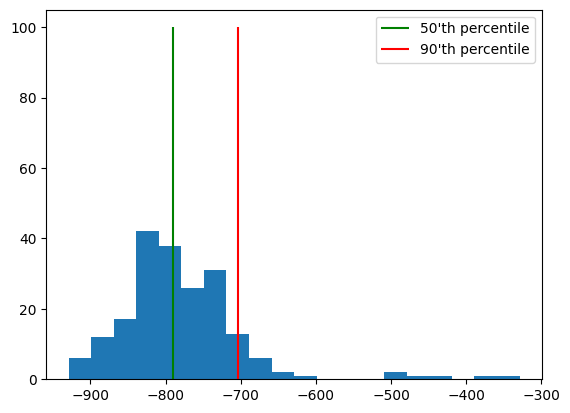

In [14]:
sample_rewards = [generate_session(env, policy, t_max=1000)[-1] for _ in range(200)]
plt.hist(sample_rewards, bins=20)
plt.vlines([np.percentile(sample_rewards, 50)], [0], [100], label="50'th percentile", color='green')
plt.vlines([np.percentile(sample_rewards, 90)], [0], [100], label="90'th percentile", color='red')
plt.legend()
plt.show()

## Шаги кросс-энтропийного метода

### Выбор состояний и действий из игры

Выбираются те состояния и действия, которые имеют награды не меньше, чем процентиль

На вход подаются:

- *states_batch* - список списков состояний сессий
- *actions_batch* - список списков действий сессий
- *rewards_batch* - список наград сессий
- *percentile* - процентиль

На выходе получаются два списка: первый содержит состояния, а второй - соответствующие им действия для лучших сессий 

In [15]:
def select_elites(states_batch, actions_batch, rewards_batch, percentile):
    assert len(states_batch) == len(actions_batch) == len(rewards_batch)  # проверка, что размерности совпадают
    
    minimum_reward = np.percentile(rewards_batch, percentile)  # минимальная награда сессии чтобы она была включена в вывод
    elite_states, elite_actions = [], []

    for i in range(len(rewards_batch)):
        if rewards_batch[i] >= minimum_reward:
            elite_states += states_batch[i]
            elite_actions += actions_batch[i]

    return elite_states, elite_actions

Тестовые игры для проверки работы функции

In [16]:
states_batch = [
    [1, 2, 3], # игра1
    [4, 2, 0, 2], # игра2
    [3, 1], # игра3
]

actions_batch = [
    [0, 2, 4], # игра1
    [3, 2, 0, 1], # игра2
    [3, 3], # игра3
]

rewards_batch = [
    3, # игра1
    4, # игра2
    5, # игра3
]

In [17]:
test_result_0 = select_elites(states_batch, actions_batch, rewards_batch, percentile=0)
test_result_30 = select_elites(states_batch, actions_batch, rewards_batch, percentile=30)
test_result_90 = select_elites(states_batch, actions_batch, rewards_batch, percentile=90)
test_result_100 = select_elites(states_batch, actions_batch, rewards_batch, percentile=100)

Для процентиля 0 должны вернуться все состояния и действия в хронологическом порядке

In [18]:
assert np.all(test_result_0[0] == [1, 2, 3, 4, 2, 0, 2, 3, 1]) and np.all(test_result_0[1] == [0, 2, 4, 3, 2, 0, 1, 3, 3])

Для процентиля 30 должны вернуться состояния и действия из последних двух игр

In [19]:
assert np.all(test_result_30[0] == [4, 2, 0, 2, 3, 1]) and np.all(test_result_30[1] == [3, 2, 0, 1, 3, 3])

Для процентиля 90 должны вернуться состояния и действия только из последней игры

In [20]:
assert np.all(test_result_90[0] == [3, 1]) and np.all(test_result_90[1] == [3, 3])

Для процентиля 100 тоже должны вернуться данные за последнюю игру. Это проверка на то, что используется именно >= в коде, а также на то, как вычисляется процентиль

In [21]:
assert np.all(test_result_100[0] == [3, 1]) and np.all(test_result_100[1] == [3, 3])

### Новая политика

В зависимости от лучших состояний и действий, полученных ранее, возвращается новая политика, где вероятности действий пропорциональны

Политика должна быть нормализована для получения действительных вероятностей и чтобы обработать случай 0/0

Для состояний, в которых никогда не находились, нужно использовать равномерное распределение 1/A как и ранее

In [22]:
def get_new_policy(elite_states, elite_actions):
    new_policy = np.zeros((n_states, n_actions), dtype=np.float64)

    for i in range(len(elite_states)):  # если действие появилось в состоянии, добавляем единичку
        new_policy[elite_states[i]][elite_actions[i]] += 1

    for state in range(n_states):  # нормализация
        sum_actions = np.sum(new_policy[state])  # сумма вхождений всех действий, она равна 0 если в состоянии никогда не были

        if np.allclose(sum_actions, 0):  # если в состоянии никогда не были, то присваиваем ему вероятности действий равномерно
            new_policy[state].fill(1/n_actions)

        else:  # нормализация, делим на сумму вхождений
            new_policy[state] /= sum_actions

    return new_policy

## Тренировочный цикл

Генерирование сеансов, выбор лучших и подстраивание под них

Функция для удобной отрисовки

In [23]:
def show_progress(rewards_batch, log, percentile, reward_range=(-990, 10)):
    mean_reward = np.mean(rewards_batch)
    threshold = np.percentile(rewards_batch, percentile)
    log.append((mean_reward, threshold))
    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1)
    plt.plot(list(zip(*log))[0], label="Mean rewards")
    plt.plot(list(zip(*log))[1], label="Reward threshold")
    plt.legend()
    plt.grid()
    plt.subplot(1, 2, 2)
    plt.hist(rewards_batch, range=reward_range)
    plt.vlines([np.percentile(rewards_batch, percentile)], [0], [100], label="Percentile", color="red")
    plt.legend()
    plt.grid()
    clear_output(True)
    print(f"Mean reward = {mean_reward}, threshold = {threshold}")
    plt.show()

In [24]:
policy = initialise_policy(n_states, n_actions)  # сброс политики на всякий случай

Эксперимент

In [25]:
n_sessions = 250
percentile = 50  # процент сессий с наивысшей наградой
learning_rate = 0.5  # насколько быстро обновляется политика
log = []

Mean reward = -53.416, threshold = 4.5


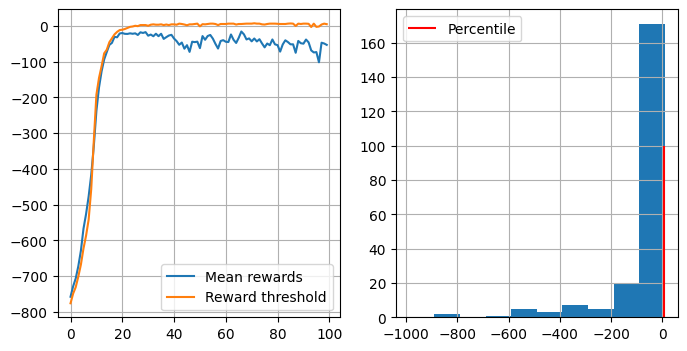

In [26]:
for i in range(100):
    sessions = [generate_session(env, policy) for _ in range(n_sessions)]
    states_batch, actions_batch, rewards_batch = zip(*sessions)
    elite_states, elite_actions = select_elites(states_batch, actions_batch, rewards_batch, percentile)
    new_policy = get_new_policy(elite_states, elite_actions)

    policy = learning_rate * new_policy + (1 - learning_rate) * policy  # обновление политики
    show_progress(rewards_batch, log, percentile)

## Почему задача сначала быстро сходится, а потом снова снижается?

Я думаю, это обусловлено переобучением, случайным выбором и скоростью обучения

Модель учится на лучших решениях, что приводит к формированию узких траекторий и потере разнообразия

Так как выбор пути стохастический, то иногда в лучшие решения может попасть случайные удачные эксперименты, потому возникает неустойчивость, ибо модель начинает обучаться на шуме, а не на реальных стратегиях

Большая скорость обучения делает проблему переобучения ещё более насущной. Я перезапустил программу несколько раз с более низкой скоростью и задача становилась более устойчивой в долгосрочной перспективе